### Multi-Agent System (create_react_agent)

In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

small_llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

E0000 00:00:1758896826.416927   29564 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.
E0000 00:00:1758896826.419936   29564 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [ ]:
from langgraph.graph import MessagesState
from langgraph.types import Command
from typing import Literal
from langchain_community.tools.yahoo_finance_news import YahooFinanceNewsTool # 랭체인 제공 도구

# Polygon.io는 다양한 자산 클래스에 걸쳐 상세하고 광범위한 데이터를 제공(API KEY 발급 요망)
# from langchain_community.agent_toolkits.polygon.toolkit import PolygonToolkit
# from langchain_community.utilities.polygon import PolygonAPIWrapper

# Polygon API를 초기화합니다.
# polygon = PolygonAPIWrapper()

# Polygon API로부터 도구 모음을 생성합니다.
# toolkit = PolygonToolkit.from_polygon_api_wrapper(polygon)

# 도구들을 가져옵니다.
# polygon_tools = toolkit.get_tools()

# 시장 조사 도구 목록을 생성합니다.
# market_research_tools = [YahooFinanceNewsTool()] + polygon_tools

market_research_tools = [YahooFinanceNewsTool()]

In [ ]:
from langgraph.prebuilt import create_react_agent
from langchain_core.prompts import ChatPromptTemplate, HumanMessage
from langchain_core.messages import SystemMessage
from langchain_core.prompts import MessagesPlaceholder # 대화 기록을 위한 Placeholder

# 에이전트의 역할을 정의하는 SystemMessage 인스턴스 생성
system_message_content = (
    "You are a professional market researcher. "
    "Your primary goal is to gather information and provide **fact-based answers only**, "
    "avoiding personal opinions or speculative analysis. "
    "You must use the provided tools to retrieve data when necessary."
)
system_message = SystemMessage(content=system_message_content)

# ChatPromptTemplate은 리스트 형태의 메시지 템플릿을 받습니다.
custom_prompt = ChatPromptTemplate.from_messages(
    [
        system_message,                      # SystemMessage 객체 자체를 리스트에 포함
        MessagesPlaceholder(variable_name="messages"), # 대화 기록을 위한 Placeholder
    ]
)

# 시장 조사 에이전트를 생성합니다.
market_research_agent = create_react_agent(
    model=llm, 
    tools=market_research_tools, 
    prompt=custom_prompt # 수정: custom_prompt 사용
)

def market_research_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    """
    시장 조사 node입니다. 주어진 state를 기반으로 시장 조사 에이전트를 호출하고,
    결과를 supervisor node로 전달합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        Command: supervisor node로 이동하기 위한 명령을 반환합니다.
    """
    # 시장 조사 에이전트를 호출하여 결과를 얻습니다.
    result = market_research_agent.invoke(state)
    
    # 결과 메시지를 업데이트하고 supervisor node로 이동합니다.
    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='market_research')]},
        goto='supervisor'
    )

In [40]:
import yfinance as yf

from langchain.tools import tool

@tool
def get_stock_price(ticker: str) -> dict:
    """Given a stock ticker, return the price data for the past month"""
    stock_info = yf.download(ticker, period='1mo').to_dict()
    return stock_info


stock_research_tools = [get_stock_price]

In [37]:
stock_research_tools[0].invoke("TSLA")

/var/folders/4p/swdn3py146z4xn6fx_rghdq40000gn/T/ipykernel_6009/2561364536.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_info = yf.download(ticker, period='1mo').to_dict()
[*********************100%***********************]  1 of 1 completed


{('Close', 'TSLA'): {Timestamp('2025-08-26 00:00:00'): 351.6700134277344,
  Timestamp('2025-08-27 00:00:00'): 349.6000061035156,
  Timestamp('2025-08-28 00:00:00'): 345.9800109863281,
  Timestamp('2025-08-29 00:00:00'): 333.8699951171875,
  Timestamp('2025-09-02 00:00:00'): 329.3599853515625,
  Timestamp('2025-09-03 00:00:00'): 334.0899963378906,
  Timestamp('2025-09-04 00:00:00'): 338.5299987792969,
  Timestamp('2025-09-05 00:00:00'): 350.8399963378906,
  Timestamp('2025-09-08 00:00:00'): 346.3999938964844,
  Timestamp('2025-09-09 00:00:00'): 346.9700012207031,
  Timestamp('2025-09-10 00:00:00'): 347.7900085449219,
  Timestamp('2025-09-11 00:00:00'): 368.80999755859375,
  Timestamp('2025-09-12 00:00:00'): 395.94000244140625,
  Timestamp('2025-09-15 00:00:00'): 410.0400085449219,
  Timestamp('2025-09-16 00:00:00'): 421.6199951171875,
  Timestamp('2025-09-17 00:00:00'): 425.8599853515625,
  Timestamp('2025-09-18 00:00:00'): 416.8500061035156,
  Timestamp('2025-09-19 00:00:00'): 426.0700

In [41]:
@tool
def get_stock_price(ticker: str) -> dict:
    """주식 티커를 받아 지난 한 달간의 가격 데이터를 딕셔너리 형태로 반환합니다."""
    # yf.download는 데이터를 DataFrame으로 반환하므로 .to_dict()로 변환합니다.
    stock_info = yf.download(ticker, period='1mo').to_dict()
    return stock_info

stock_research_tools = [get_stock_price]

# 에이전트의 역할을 정의하는 SystemMessage 인스턴스 생성
system_message_content = (
    "You are an expert financial and stock researcher. "
    "Your task is to utilize the 'get_stock_price' tool to fetch stock data. "
    "Provide analysis and answers **based on the retrieved facts and data only**. "
    "Do not offer investment advice, opinions, or speculative forecasts."
)
system_message = SystemMessage(content=system_message_content)

# ChatPromptTemplate 구성
custom_prompt = ChatPromptTemplate.from_messages(
    [
        system_message,
        MessagesPlaceholder(variable_name="messages"),
    ]
)

# 주식 조사 에이전트를 생성합니다. (state_modifier 제거 및 prompt 인자 사용)
stock_research_agent = create_react_agent(
    model=llm, 
    tools=stock_research_tools, 
    prompt=custom_prompt # 수정: 사용자 지정 프롬프트 사용
)

def stock_research_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    """
    주식 조사 node입니다. 주어진 State를 기반으로 주식 조사 에이전트를 호출하고,
    결과를 supervisor node로 전달합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        Command: supervisor node로 이동하기 위한 명령을 반환합니다.
    """
    result = stock_research_agent.invoke(state)

    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='stock_research')]},
        goto='supervisor'
    )

In [42]:
@tool
def company_research_tool(ticker: str) -> dict:
    """Given a ticker, return the financial information and SEC filings"""
    company_info = yf.Ticker(ticker)
    financial_info = company_info.get_financials()
    sec_filings = company_info.get_sec_filings()
    return {
        'financial_info': financial_info,
        'sec_filings': sec_filings
    }

company_research_tools = [company_research_tool]

# 에이전트의 역할을 정의하는 SystemMessage 인스턴스 생성
system_message_content = (
    "You are an expert company researcher. "
    "Your primary goal is to use the 'company_research_tool' to fetch and summarize "
    "corporate financial information and SEC filings for the given ticker. "
    "You must provide answers **based on the retrieved facts and data only** "
    "and should not offer any personal opinions or speculative commentary."
)
system_message = SystemMessage(content=system_message_content)

# ChatPromptTemplate 구성
custom_prompt = ChatPromptTemplate.from_messages(
    [
        system_message,
        MessagesPlaceholder(variable_name="messages"),
    ]
)

# 회사 조사 에이전트를 생성합니다. (state_modifier 제거 및 prompt 인자 사용)
company_research_agent = create_react_agent(
    model=llm, 
    tools=company_research_tools, 
    prompt=custom_prompt # 수정: 사용자 지정 프롬프트 사용
)

def company_research_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    """
    회사 조사 node입니다. 주어진 State를 기반으로 회사 조사 에이전트를 호출하고,
    결과를 supervisor node로 전달합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        Command: supervisor node로 이동하기 위한 명령을 반환합니다.
    """
    result = company_research_agent.invoke(state)

    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='company_research')]},
        goto='supervisor'
    )

In [47]:
from langchain_core.prompts import PromptTemplate

analyst_prompt = PromptTemplate.from_template(
    """You are a stock market analyst. Given the following information, 
Please decide wheter to buy, sell, or hold the stock.

Important Instruction: **Your final answer MUST be in KOREAN (한글) and should only contain the final decision (매수, 매도, 또는 보유) and a brief, professional justification.**

Information:
{messages}"""
)

analyst_chain = analyst_prompt | llm

def analyst_node(state: MessagesState):
    """
    분석가 node입니다. 주어진 State를 기반으로 분석가 체인을 호출하고,
    결과 메시지를 반환합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        dict: 분석 결과 메시지를 포함하는 딕셔너리를 반환합니다.
    """
    result = analyst_chain.invoke({'messages': state['messages'][1:]})

    return {'messages': [result]}

In [48]:
from typing import Literal
from typing_extensions import TypedDict

from langgraph.graph import MessagesState, END
from langgraph.types import Command


members = ["market_research", "stock_research", "company_research"]
options = members + ["FINISH"]

system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    f" following workers: {members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)


class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""

    next: Literal[*options]



def supervisor_node(state: MessagesState) -> Command[Literal[*members, "analyst"]]:
    """
    supervisor node입니다. 주어진 State를 기반으로 각 worker의 결과를 종합하고,
    다음에 수행할 worker를 결정합니다. 모든 작업이 완료되면 analyst node로 이동합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        Command: 다음에 수행할 worker 또는 analyst node로 이동하기 위한 명령을 반환합니다.
    """
    messages = [
        {"role": "system", "content": system_prompt},
    ] + state["messages"]
    response = llm.with_structured_output(Router).invoke(messages)
    goto = response["next"]
    if goto == "FINISH":
        goto = "analyst"

    return Command(goto=goto)

In [49]:
from langgraph.graph import StateGraph, START

graph_builder = StateGraph(MessagesState)

graph_builder.add_node("supervisor", supervisor_node)
graph_builder.add_node("market_research", market_research_node)
graph_builder.add_node("stock_research", stock_research_node)
graph_builder.add_node("company_research", company_research_node)
graph_builder.add_node("analyst", analyst_node)

In [50]:
graph_builder.add_edge(START, "supervisor")
graph_builder.add_edge("analyst", END)
graph = graph_builder.compile()


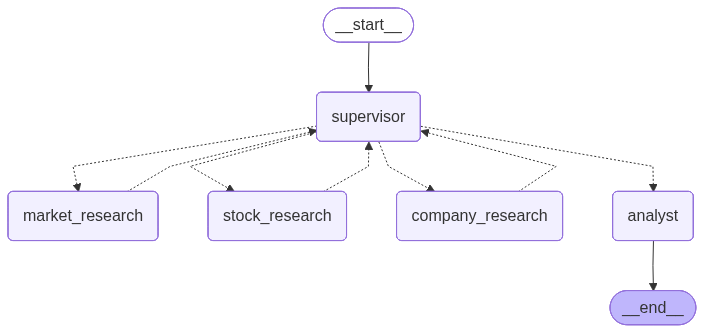

In [ ]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

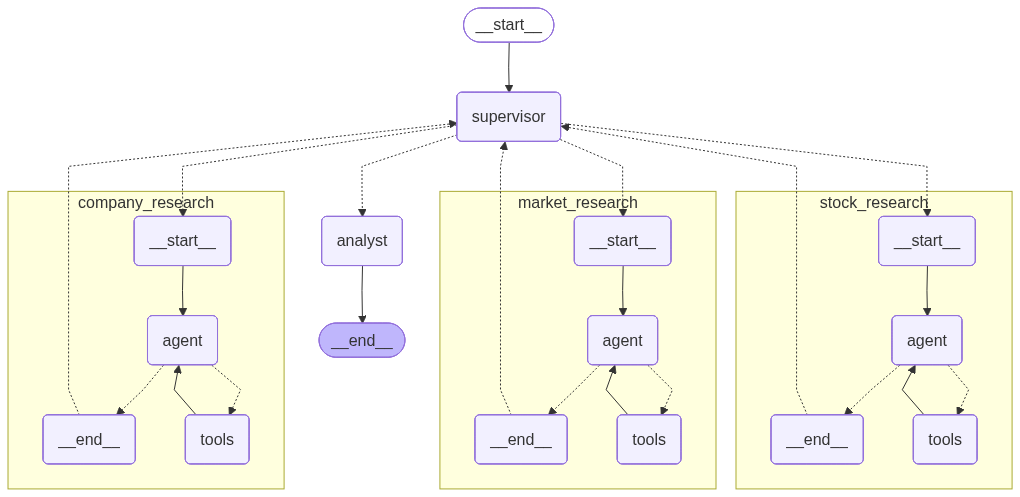

In [44]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [51]:
for chunk in graph.stream(
    {"messages": [("user", "테슬라 주식에 투자할까?")]}, stream_mode="values"
):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

테슬라 주식에 투자할까?
================================ Human Message =================================
Name: company_research

저는 투자 조언을 드릴 수 없습니다. 하지만 테슬라의 재무 정보와 SEC 보고서를 찾아드릴 수 있습니다. 정보를 찾아드릴까요?
================================ Human Message =================================
Name: company_research

저는 투자 조언을 드릴 수 없습니다. 하지만 테슬라의 재무 정보와 SEC 보고서를 찾아드릴 수 있습니다. 정보를 찾아드리겠습니다.
================================ Human Message =================================
Name: company_research

테슬라(TSLA)의 재무 정보와 SEC 보고서를 요약해 드리겠습니다.

**재무 정보 요약 (2020년 ~ 2024년 예상치):**

*   **총 매출 (Total Revenue):**
    *   2024년(예상): 976.9억 달러
    *   2023년: 967.73억 달러
    *   2022년: 814.62억 달러
    *   2021년: 538.23억 달러
    *   총 매출은 꾸준히 증가하는 추세입니다.

*   **매출 총 이익 (Gross Profit):**
    *   2024년(예상): 174.5억 달러
    *   2023년: 176.6억 달러
    *   2022년: 208.53억 달러
    *   2021년: 136.06억 달러
    *   매출 총 이익은 2022년에 정점을 찍고 2023년과 2024년(예상)에는 소폭 감소했습니다.

* 

In [53]:
query = "테슬라(Tesla) 주식의 티커(TSLA)를 사용하여 get_stock_price 도구를 호출하고, 지난 한 달간의 가격 데이터를 검색하십시오. 검색된 데이터(시가, 종가, 거래량 등)를 분석하여 주가 변동 추이에 대한 사실 기반의 간결한 요약을 작성하십시오."

In [54]:
for chunk in graph.stream(
    {"messages": [("user", query)]}, stream_mode="values"
):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

테슬라(Tesla) 주식의 티커(TSLA)를 사용하여 get_stock_price 도구를 호출하고, 지난 한 달간의 가격 데이터를 검색하십시오. 검색된 데이터(시가, 종가, 거래량 등)를 분석하여 주가 변동 추이에 대한 사실 기반의 간결한 요약을 작성하십시오.


/var/folders/4p/swdn3py146z4xn6fx_rghdq40000gn/T/ipykernel_6009/3758245821.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_info = yf.download(ticker, period='1mo').to_dict()
[*********************100%***********************]  1 of 1 completed


================================ Human Message =================================
Name: stock_research

테슬라(TSLA) 주식은 지난 한 달 동안 변동성을 보였으며, 초기 하락 후 상당한 상승세를 기록했습니다.

**주요 관찰 내용:**

*   **초기 하락 (8월 말 ~ 9월 초):** 8월 26일 종가 351.67달러에서 시작하여 9월 2일에는 329.36달러로 하락하며 최저점을 기록했습니다. 이 기간 동안 거래량은 상대적으로 안정적이거나 약간 감소했습니다.
*   **중순 상승 (9월 11일 ~ 9월 17일):** 9월 10일 종가 347.79달러에서 9월 11일 368.81달러로 크게 상승하기 시작했습니다. 이 상승세는 9월 12일에 395.94달러, 9월 15일에 410.04달러, 9월 17일에 425.86달러로 이어졌습니다. 이 기간 동안 거래량은 9월 12일 1억 6,815만 주를 기록하며 크게 증가했습니다.
*   **후반 변동 (9월 18일 ~ 9월 26일):** 9월 중순의 급격한 상승 이후 주가는 높은 수준에서 등락을 거듭했습니다. 최고 종가는 9월 24일 442.79달러였으며, 9월 26일에는 429.13달러로 마감했습니다. 후반부의 거래량은 중순의 최고치보다는 낮았지만, 초기 기간보다는 높은 수준을 유지했습니다.

**종합 요약:**
테슬라(TSLA) 주식은 지난 한 달 동안 8월 말과 9월 초에 소폭 하락한 후 9월 중순에 걸쳐 약 329달러에서 425달러 이상으로 크게 상승했습니다. 특히 9월 11일부터 17일까지 급격한 가격 상승과 함께 거래량이 크게 증가하는 양상을 보였습니다. 이후 9월 말에는 높은 수준에서 등락을 반복하며, 초기 대비 상당한 가격 상승으로 한 달을 마감했습니다.
================================== Ai Message ==================================

보유. 최근 강한 상승세